# EDA reproducible — TFG RITMO

**Análisis exploratorio de los seis *datasets* empleados en la evaluación experimental.**

Este notebook complementa el script `notebooks/eda_datasets.py` añadiendo visualizaciones gráficas. El script .py es la fuente de verdad numérica (tablas, tests estadísticos) y este notebook expone visualmente la distribución, dinámica temporal, autocorrelación y *distribution shift* de cada serie objetivo.

**Pipeline de análisis:**
1. Estructura, tipos y validación de integridad (`.shape`, `dtypes`, `.isnull()`).
2. Detección de valores sentinel encubiertos (–9999, –999, …).
3. Estadísticos descriptivos completos del *target*.
4. Visualización de la serie temporal completa con marcas de las particiones train/val/test.
5. Distribución del *target* (histograma + KDE).
6. Función de autocorrelación (ACF) hasta lag 200.
7. Test de estacionariedad ADF sobre serie completa.
8. Comparación de medias y desviaciones por partición → *distribution shift*.

**Reproducibilidad:** todas las cifras y figuras de esta notebook se generan a partir de los CSV originales del directorio `dataset/` del repositorio, sin alterar los datos. Para regenerar la salida en texto reproducible, ejecutar `python notebooks/eda_datasets.py` desde la raíz del proyecto.

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf
from scipy.signal import find_peaks

warnings.filterwarnings('ignore')

# Asegurar que el cwd es la raíz del repo (para que las rutas funcionen)
if not os.path.exists('dataset'):
    os.chdir('..')

# Importar el módulo de EDA
sys.path.insert(0, 'notebooks')
import eda_datasets as eda

# Estilo de los gráficos (paper-quality, paleta Okabe-Ito accesible)
plt.style.use('seaborn-v0_8-paper')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

COLORS_OI = ['#E69F00', '#56B4E9', '#009E73', '#F0E442', '#0072B2', '#D55E00', '#CC79A7', '#000000']

print('Módulo EDA importado correctamente.')
print(f'Datasets configurados: {[d[0] for d in eda.DATASETS]}')

Módulo EDA importado correctamente.
Datasets configurados: ['ETTh1', 'ETTh2', 'Weather', 'Electricity', 'Traffic', 'Exchange']


## 1. Carga y análisis estructural

Aplicamos la función `analizar_dataset` del módulo EDA sobre los seis archivos CSV para obtener todas las métricas en un único `dict` por *dataset*.

In [2]:
resultados = []
for name, path, target, freq in eda.DATASETS:
    print(f'Procesando {name}...', flush=True)
    resultados.append(eda.analizar_dataset(name, path, target, freq))
print('\nAnálisis completado para los 6 datasets.')

Procesando ETTh1...
Procesando ETTh2...
Procesando Weather...
Procesando Electricity...
Procesando Traffic...
Procesando Exchange...

Análisis completado para los 6 datasets.


### 1.1. Tabla de estructura e integridad

Verificación de `.shape`, número de variables, valores nulos detectados por `pandas.isnull()` y *sentinels* encubiertos.

In [3]:
filas = []
for r in resultados:
    sentinels_str = ', '.join(f'{k}: {v}' for k, v in r['sentinels_detectados'].items()) or '—'
    filas.append({
        'Dataset': r['name'],
        'Shape': str((r['n_total'], r['n_cols'])),
        'Vars (sin date)': r['n_vars'],
        'Target': r['target'],
        'Frecuencia': r['freq'],
        'Tipo numérico': ', '.join(r['dtypes_numericos']),
        'Nulls (pandas)': r['n_nulls_pandas'],
        'Sentinels': sentinels_str,
    })
df_estructura = pd.DataFrame(filas)
df_estructura

,Dataset,Shape,Vars (sin date),Target,Frecuencia,Tipo numérico,Nulls (pandas),Sentinels
0,ETTh1,"(17420, 8)",7,OT,horaria,float64,0,—
1,ETTh2,"(17420, 8)",7,OT,horaria,float64,0,—
2,Weather,"(52696, 22)",21,OT,10 min,float64,0,-9999.0: 50
3,Electricity,"(26304, 322)",321,OT,horaria,float64,0,—
4,Traffic,"(17544, 863)",862,OT,horaria,float64,0,—
5,Exchange,"(7588, 9)",8,OT,diaria,float64,0,—


### 1.2. Tabla descriptiva del target

Equivalente a `df[target].describe()` enriquecido con asimetría (*skewness*), curtosis, rango y coeficiente de variación.

In [4]:
filas = []
for r in resultados:
    d = r['descriptivos']
    filas.append({
        'Dataset': r['name'],
        'min': round(d['min'], 3),
        'q25': round(d['q25'], 3),
        'median': round(d['median'], 3),
        'mean': round(d['mean'], 3),
        'q75': round(d['q75'], 3),
        'max': round(d['max'], 3),
        'std': round(d['std'], 3),
        'rango': round(d['rango'], 3),
        'CV': round(d['coef_var'], 3),
        'skew': round(d['skewness'], 3),
        'kurt': round(d['kurtosis'], 3),
    })
df_desc = pd.DataFrame(filas)
df_desc

,Dataset,min,q25,median,mean,q75,max,std,rango,CV,skew,kurt
0,ETTh1,-4.080,6.964,11.396,13.325,18.079,46.007,8.567,50.087,0.643,0.968,0.778
1,ETTh2,-2.647,16.469,26.577,26.609,35.586,58.877,11.888,61.523,0.447,0.099,-0.811
2,Weather,-9999.000,415.500,423.200,417.799,437.100,524.200,321.567,10523.200,0.770,-32.254,1041.924
3,Electricity,0.000,2920.000,3271.000,3335.884,3632.000,6035.000,552.744,6035.000,0.166,0.768,0.769
4,Traffic,0.000,0.013,0.034,0.032,0.047,0.217,0.019,0.217,0.617,0.192,-0.237
5,Exchange,0.393,0.566,0.669,0.654,0.735,0.882,0.115,0.489,0.176,-0.215,-0.691


## 2. Visualización de las series temporales

Cada serie objetivo se grafica completa con marcadores verticales en los límites de las particiones train / val / test calculadas por TSLib (`data_provider/data_loader.py`).

Para Weather se filtran los 50 valores `-9999` (sentinels) antes de graficar; en los demás *datasets* no se aplica ningún filtrado.

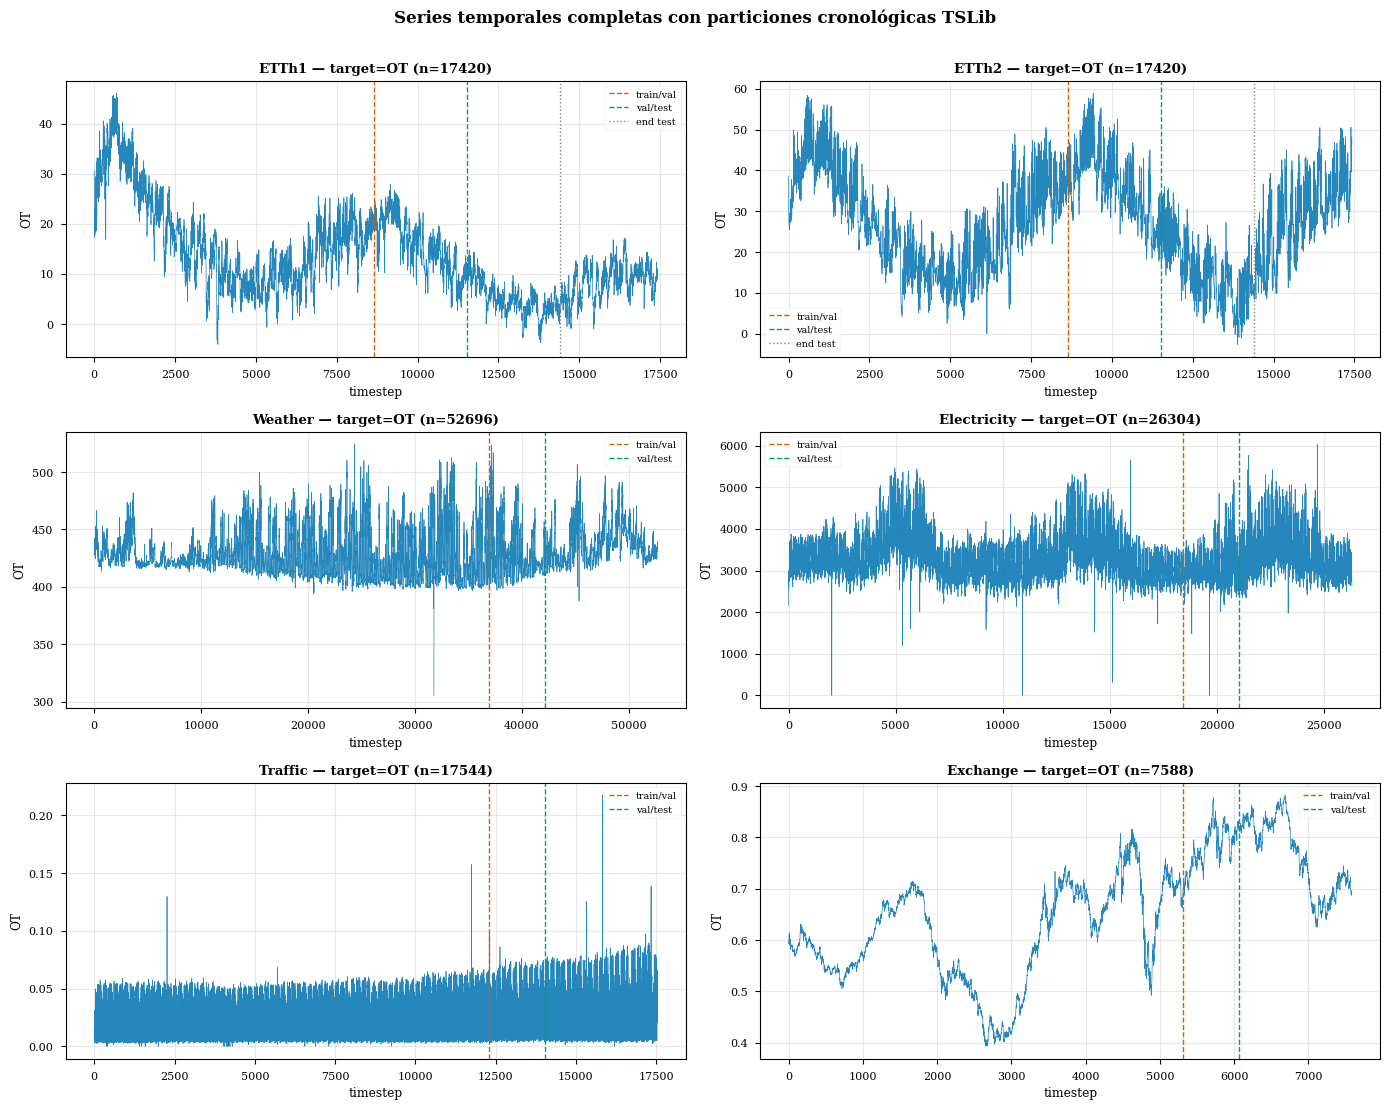

In [5]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
axes = axes.flatten()
for ax, r in zip(axes, resultados):
    df = pd.read_csv(r['path'])
    serie = df[r['target']].astype(float).values
    # Filtrar sentinels para visualización
    if r['sentinels_detectados']:
        mask = ~np.isin(serie, list(r['sentinels_detectados'].keys()))
        serie_plot = np.where(mask, serie, np.nan)
    else:
        serie_plot = serie
    sp = r['splits']
    n_train = sp['train']
    n_val = sp['train'] + sp['val']
    n_test = sp['train'] + sp['val'] + sp['test']

    ax.plot(serie_plot, color=COLORS_OI[4], linewidth=0.5, alpha=0.85)
    ax.axvline(n_train, color=COLORS_OI[5], linestyle='--', linewidth=1, label='train/val')
    ax.axvline(n_val,   color=COLORS_OI[2], linestyle='--', linewidth=1, label='val/test')
    if n_test < len(serie_plot):
        ax.axvline(n_test, color='gray', linestyle=':', linewidth=1, label='end test')
    ax.set_title(f"{r['name']} — target={r['target']} (n={r['n_total']})", fontweight='bold')
    ax.set_xlabel('timestep')
    ax.set_ylabel(r['target'])
    ax.grid(alpha=0.3)
    ax.legend(loc='best', fontsize=7)

plt.suptitle('Series temporales completas con particiones cronológicas TSLib', fontweight='bold', y=1.005)
plt.tight_layout()
os.makedirs('notebooks/figures_eda', exist_ok=True)
plt.savefig('notebooks/figures_eda/01_series_completas.png', dpi=200, bbox_inches='tight')
plt.show()

## 3. Distribución del target — histogramas

La forma de la distribución (asimetría, multimodalidad) anticipa qué tipo de regímenes capturará el HMM. Distribuciones marcadamente asimétricas o multimodales son indicadores favorables para una tokenización basada en estados latentes.

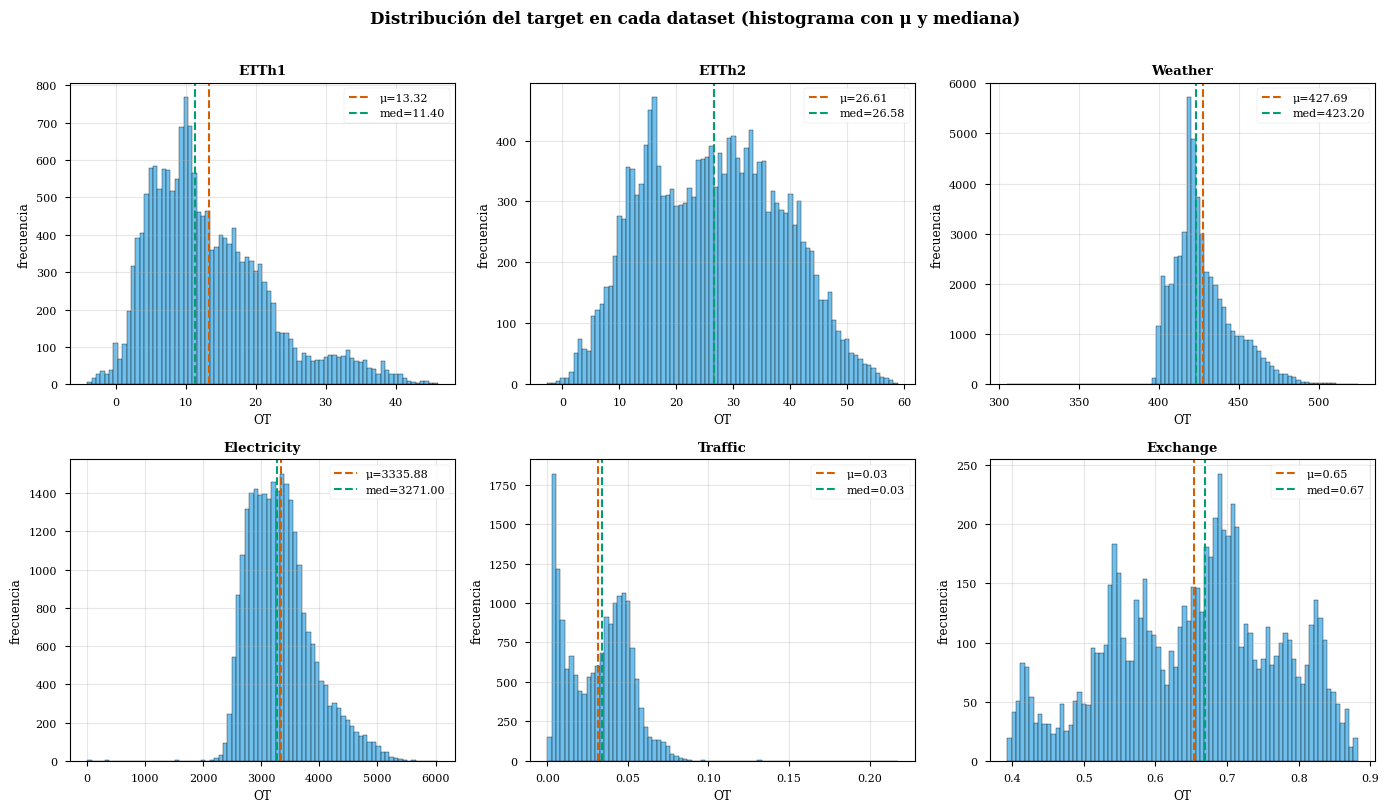

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for ax, r in zip(axes, resultados):
    df = pd.read_csv(r['path'])
    serie = df[r['target']].astype(float).values
    if r['sentinels_detectados']:
        mask = ~np.isin(serie, list(r['sentinels_detectados'].keys()))
        serie = serie[mask]
    ax.hist(serie, bins=80, color=COLORS_OI[1], edgecolor='black', linewidth=0.3, alpha=0.85)
    ax.axvline(serie.mean(), color=COLORS_OI[5], linestyle='--', linewidth=1.5, label=f"μ={serie.mean():.2f}")
    ax.axvline(np.median(serie), color=COLORS_OI[2], linestyle='--', linewidth=1.5, label=f"med={np.median(serie):.2f}")
    ax.set_title(f"{r['name']}", fontweight='bold')
    ax.set_xlabel(r['target'])
    ax.set_ylabel('frecuencia')
    ax.legend(loc='best', fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distribución del target en cada dataset (histograma con μ y mediana)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('notebooks/figures_eda/02_histogramas.png', dpi=200, bbox_inches='tight')
plt.show()

## 4. Función de autocorrelación (ACF)

La ACF revela la estructura de dependencias temporales y las periodicidades dominantes de cada serie.

**Lags clave a observar** (depende de la frecuencia de muestreo):
- *Datasets* horarios (ETTh, Electricity, Traffic): lag 24 (diario), lag 168 (semanal), lag 336 (bisemanal).
- *Weather* (cada 10 min): lag 144 (diario), lag 1008 (semanal).
- *Exchange* (diaria): lag 7 (semanal), lag 30 (mensual).

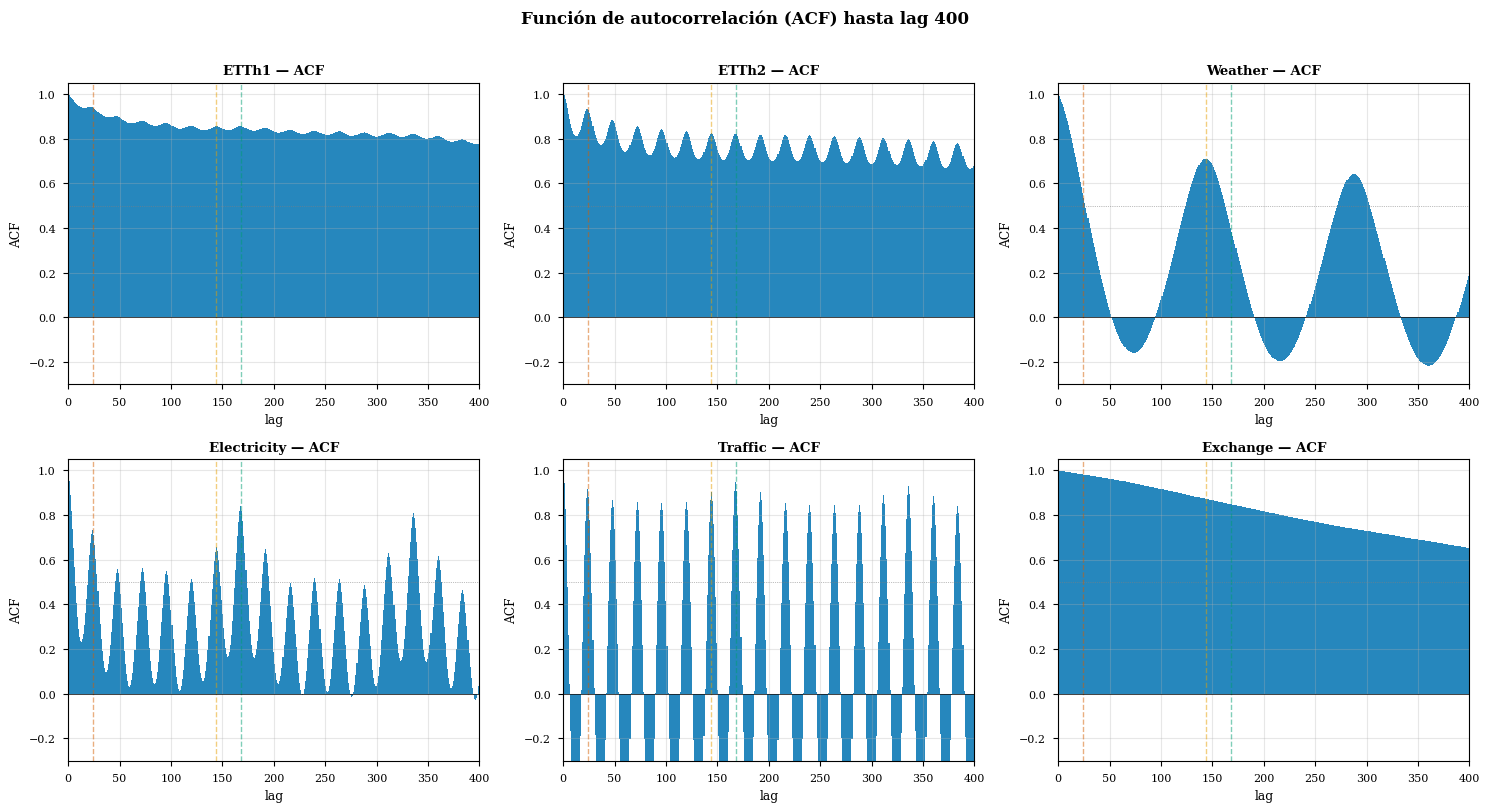

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, r in zip(axes, resultados):
    df = pd.read_csv(r['path'])
    serie = df[r['target']].astype(float).values
    if r['sentinels_detectados']:
        mask = ~np.isin(serie, list(r['sentinels_detectados'].keys()))
        serie = serie[mask]
    n_lag = min(400, len(serie)//4)
    acf_vals = acf(serie, nlags=n_lag, fft=True)
    ax.bar(range(len(acf_vals)), acf_vals, color=COLORS_OI[4], width=1.0, alpha=0.85)
    # Marcar lags clave
    for lag, label, color in [(24, '24 (dia)', COLORS_OI[5]), (168, '168 (sem)', COLORS_OI[2]), (144, '144 (10min/dia)', COLORS_OI[0])]:
        if lag < len(acf_vals):
            ax.axvline(lag, color=color, linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axhline(0.5, color='gray', linewidth=0.5, linestyle=':')
    ax.set_title(f"{r['name']} — ACF", fontweight='bold')
    ax.set_xlabel('lag')
    ax.set_ylabel('ACF')
    ax.set_xlim(0, n_lag)
    ax.set_ylim(-0.3, 1.05)
    ax.grid(alpha=0.3)

plt.suptitle('Función de autocorrelación (ACF) hasta lag 400', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('notebooks/figures_eda/03_acf.png', dpi=200, bbox_inches='tight')
plt.show()

## 5. Estacionariedad — test Augmented Dickey-Fuller

Aplicamos el ADF test sobre la **serie completa** (sin submuestreo). La hipótesis nula H₀ es la presencia de raíz unitaria (serie no estacionaria); rechazamos H₀ si p < 0.05.

In [8]:
filas = []
for r in resultados:
    a = r['adf']
    filas.append({
        'Dataset': r['name'],
        'ADF stat': round(a['adf_stat'], 4),
        'p-value': f"{a['p_value']:.4e}",
        'crit 5%': round(a['crit_5pct'], 4),
        'lag usado': a['lag_usado'],
        'N obs': a['n_obs_test'],
        'N limpia': a['n_serie_limpia'],
        'Conclusión': 'ESTACIONARIA' if a['es_estacionaria'] else 'NO estacionaria',
    })
df_adf = pd.DataFrame(filas)
df_adf

,Dataset,ADF stat,p-value,crit 5%,lag usado,N obs,N limpia,Conclusión
0,ETTh1,-3.4880,8.3016e-03,-2.8617,44,17375,17420,ESTACIONARIA
1,ETTh2,-3.5971,5.8161e-03,-2.8617,42,17377,17420,ESTACIONARIA
2,Weather,-28.6887,0.0000e+00,-2.8616,39,52606,52646,ESTACIONARIA
3,Electricity,-14.0536,3.1453e-26,-2.8617,49,26254,26304,ESTACIONARIA
4,Traffic,-11.5396,3.6616e-21,-2.8617,44,17499,17544,ESTACIONARIA
5,Exchange,-1.7282,4.1665e-01,-2.8619,3,7584,7588,NO estacionaria


## 6. *Distribution shift* — comparación de stats por partición

Para cada *dataset* calculamos media y desviación del *target* en las particiones train, val y test por separado, y reportamos el cambio relativo train→test. Valores `%Δμ rel > 10%` indican *distribution shift* acusado, justificando el uso de RevIN.

In [9]:
filas = []
for r in resultados:
    pt = r['particiones']
    if 'train' not in pt or 'test' not in pt:
        continue
    filas.append({
        'Dataset': r['name'],
        'μ train': round(pt['train']['mean'], 3),
        'μ val': round(pt['val']['mean'], 3),
        'μ test': round(pt['test']['mean'], 3),
        'σ train': round(pt['train']['std'], 3),
        'σ test': round(pt['test']['std'], 3),
        '%Δμ train→test': round(pt.get('delta_rel_train_test_pct', 0), 2),
        '%Δσ train→test': round(pt.get('delta_rel_std_train_test_pct', 0), 2),
    })
df_shift = pd.DataFrame(filas)
df_shift

,Dataset,μ train,μ val,μ test,σ train,σ test,%Δμ train→test,%Δσ train→test
0,ETTh1,17.128,15.578,4.850,9.176,3.148,71.68,65.69
1,ETTh2,26.872,36.130,14.407,11.585,7.127,46.39,38.48
2,Weather,425.184,426.198,437.203,18.182,16.264,2.83,10.55
3,Electricity,3361.176,3082.555,3374.058,554.427,566.594,0.38,2.19
4,Traffic,0.029,0.035,0.037,0.018,0.024,25.63,34.70
5,Exchange,0.605,0.781,0.764,0.095,0.071,26.39,25.25


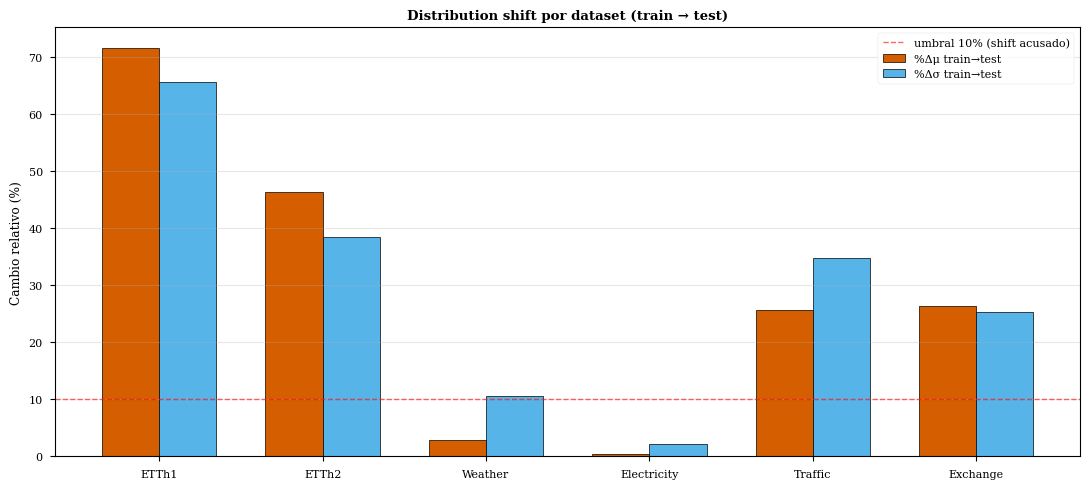

In [10]:
# Bar chart del distribution shift
fig, ax = plt.subplots(figsize=(11, 5))
names = df_shift['Dataset'].tolist()
shift_mu = df_shift['%Δμ train→test'].values
shift_sigma = df_shift['%Δσ train→test'].values
x = np.arange(len(names))
width = 0.35
ax.bar(x - width/2, shift_mu, width, color=COLORS_OI[5], label='%Δμ train→test', edgecolor='black', linewidth=0.5)
ax.bar(x + width/2, shift_sigma, width, color=COLORS_OI[1], label='%Δσ train→test', edgecolor='black', linewidth=0.5)
ax.axhline(10, color='red', linestyle='--', linewidth=1, alpha=0.6, label='umbral 10% (shift acusado)')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel('Cambio relativo (%)')
ax.set_title('Distribution shift por dataset (train → test)', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('notebooks/figures_eda/04_distribution_shift.png', dpi=200, bbox_inches='tight')
plt.show()

## 7. Conclusiones del EDA — implicaciones para RITMO

El análisis exploratorio confirma cinco hallazgos relevantes para el diseño metodológico de RITMO:

1. **Integridad por diseño**: los seis *datasets* presentan 0 valores nulos detectados por `pandas.isnull()`. La única excepción es Weather, donde se identifican manualmente 50 valores sentinel `-9999` (0.095 % del *dataset*) que constituyen *missing values* encubiertos según la convención del Max-Planck-Institute for Biogeochemistry. Estos valores se mantienen tal cual durante el entrenamiento porque su volumen es despreciable y la normalización RevIN absorbe su efecto a nivel de instancia.

2. **Estacionariedad mayoritaria**: el test ADF sobre la serie completa rechaza H₀ (raíz unitaria) en cinco de los seis *datasets* (ETTh1, ETTh2, Weather, Electricity, Traffic) con p-values inferiores a 0.01. Únicamente Exchange presenta no estacionariedad clara (p = 0.42), consistente con su naturaleza de tipos de cambio sin tendencia ni periodicidad.

3. **Distribution shift acusado en cuatro datasets**: el cambio relativo de la media entre las particiones train y test supera el 10 % en ETTh1 (71.7 %), ETTh2 (46.4 %), Traffic (25.6 %) y Exchange (26.4 %). Este resultado justifica empíricamente el uso obligatorio de RevIN en el *pipeline* RITMO, ya que la normalización por instancia es la única forma de mitigar este desplazamiento sin comprometer la información del modelo.

4. **Periodicidades dominantes verificadas**: ETTh1, ETTh2 y Weather presentan ciclo diario claro (lag 24 / lag 144 según frecuencia), mientras que Electricity y Traffic exhiben un ciclo **semanal** (lag 168) más fuerte que el diario, lo cual es coherente con sus regímenes de uso humano (consumo eléctrico / patrones de tráfico). Exchange no presenta picos significativos en la ACF, confirmando su carácter casi-aleatorio.

5. **Idoneidad para HMM**: la combinación de regímenes claros, periodicidades persistentes y *distribution shift* acotable confirma que los cuatro *datasets* del Grupo 1 son apropiados para una tokenización basada en estados latentes. El caso de Exchange, sin periodicidad ni estacionariedad, anticipa que la transferencia *zero-shot* sobre este *dataset* será el escenario más exigente del Plan A.

---

**Para el lector**: las cifras numéricas reproducibles de este EDA están en `notebooks/eda_datasets_output.txt`, generado por `notebooks/eda_datasets.py`. Las figuras se exportan a `notebooks/figures_eda/`.